Clinical Readmission Prediction — Complete Machine Learning Pipeline

1. Import Libraries

In [1]:
# pip install shap --default-timeout=100

In [13]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Explainability
from sklearn.inspection import permutation_importance
import shap

import warnings
warnings.filterwarnings('ignore')

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2. Load Dataset

In [14]:
# Load dataset
file_path = 'hospital_readmission_dataset.csv'
df = pd.read_csv(file_path)

# Display first rows
df.head()

,patient_id,admission_date,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label
0,P00001,2022-04-14,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1
1,P00002,2021-09-19,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1
2,P00003,2023-04-12,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1
3,P00004,2023-08-14,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1
4,P00005,2021-11-05,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1


3. Basic Dataset Information

In [16]:
print('Dataset Shape:') 
df.shape

Dataset Shape:


(8000, 17)

In [18]:
print('\nColumns:')
df.columns


Columns:


Index(['patient_id', 'admission_date', 'season', 'age', 'gender', 'region',
       'primary_diagnosis', 'comorbidities_count', 'length_of_stay',
       'treatment_type', 'medications_count', 'followup_visits_last_year',
       'prev_readmissions', 'insurance_type', 'discharge_disposition',
       'readmission_risk_score', 'label'],
      dtype='str')

In [20]:
print('\nData Types:')
df.dtypes


Data Types:


patient_id                       str
admission_date                   str
season                           str
age                            int64
gender                           str
region                           str
primary_diagnosis                str
comorbidities_count            int64
length_of_stay                 int64
treatment_type                   str
medications_count              int64
followup_visits_last_year      int64
prev_readmissions              int64
insurance_type                   str
discharge_disposition            str
readmission_risk_score       float64
label                          int64
dtype: object

4. Missing Values

In [21]:
missing_values = df.isnull().sum()
missing_values

patient_id                   0
admission_date               0
season                       0
age                          0
gender                       0
region                       0
primary_diagnosis            0
comorbidities_count          0
length_of_stay               0
treatment_type               0
medications_count            0
followup_visits_last_year    0
prev_readmissions            0
insurance_type               0
discharge_disposition        0
readmission_risk_score       0
label                        0
dtype: int64

5. Statistical Summary

In [22]:
df.describe()

,age,comorbidities_count,length_of_stay,medications_count,followup_visits_last_year,prev_readmissions,readmission_risk_score,label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000
mean,57.411625,4.318500,7.789125,7.475750,3.638125,1.57250,0.776937,0.772875
std,16.724388,1.358046,1.930252,2.287917,1.630415,0.89196,0.219885,0.419000
min,18.000000,1.000000,3.000000,2.000000,0.000000,0.00000,0.070000,0.000000
25%,46.000000,3.000000,6.000000,6.000000,2.000000,1.00000,0.630000,1.000000
50%,57.000000,4.000000,8.000000,8.000000,4.000000,1.00000,0.860000,1.000000
75%,69.000000,5.000000,9.000000,9.000000,4.000000,2.00000,0.970000,1.000000
max,95.000000,10.000000,15.000000,18.000000,10.000000,5.00000,0.970000,1.000000


6. Target Variable Distribution

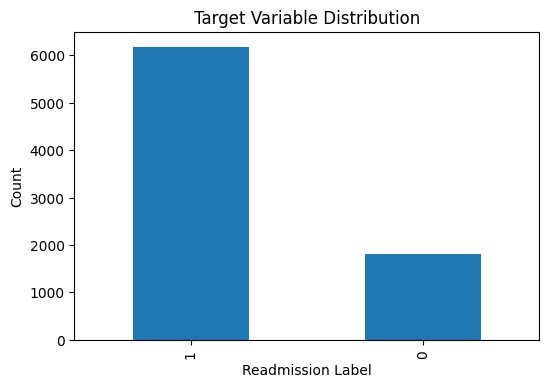

In [23]:
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Readmission Label')
plt.ylabel('Count')
plt.show()

7. Correlation Heatmap

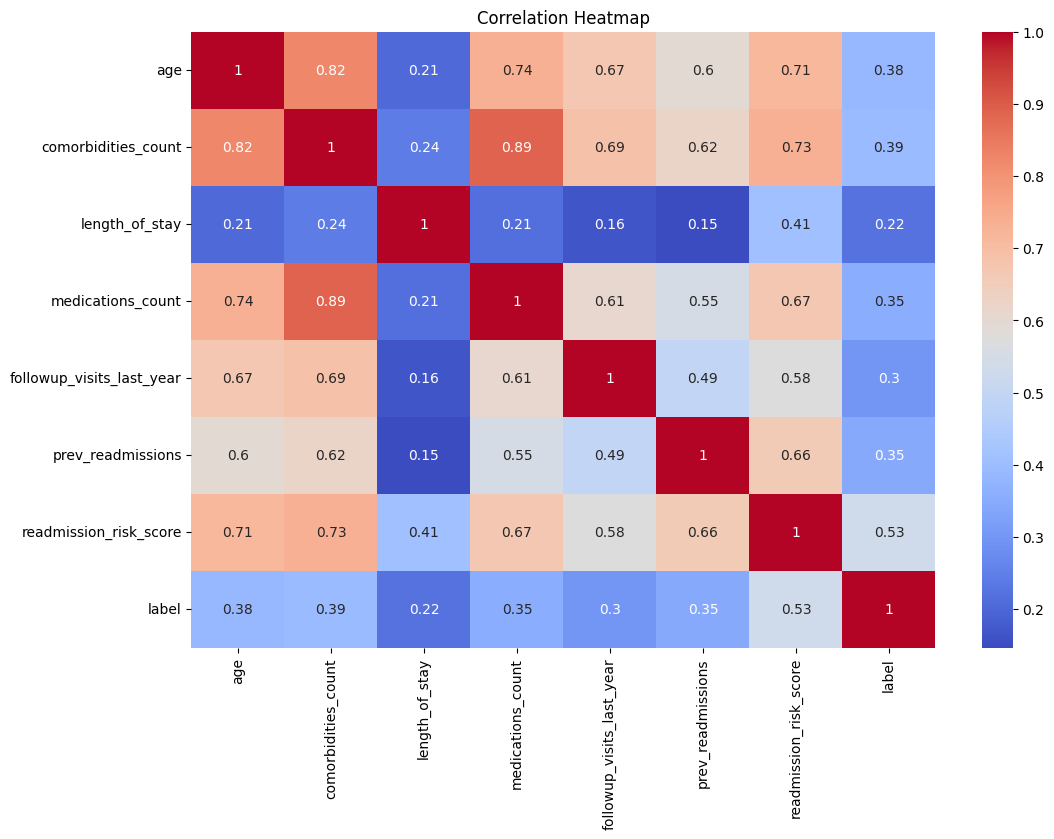

In [24]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

8. Age Distribution

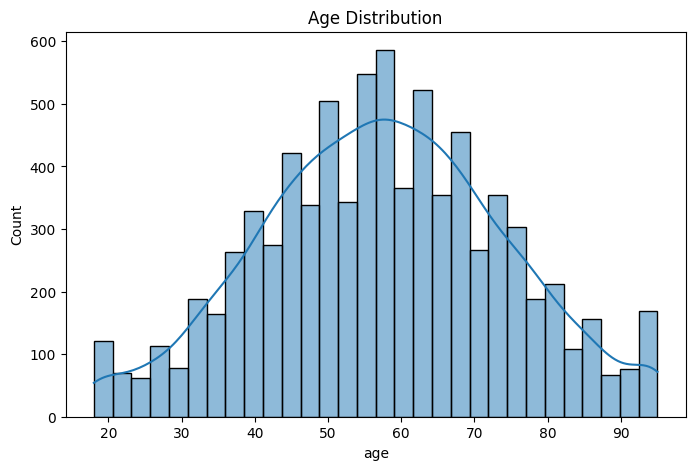

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

9. Readmission by Gender

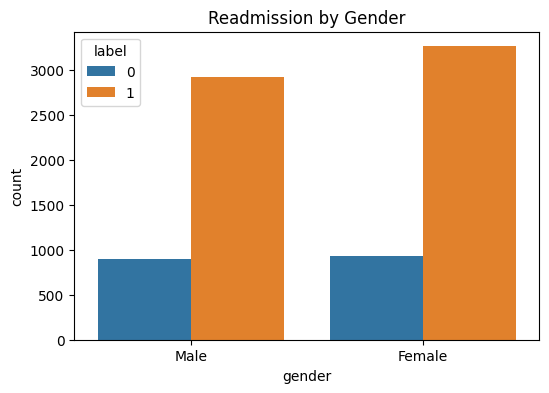

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', hue='label')
plt.title('Readmission by Gender')
plt.show()

10. Readmission by Diagnosis

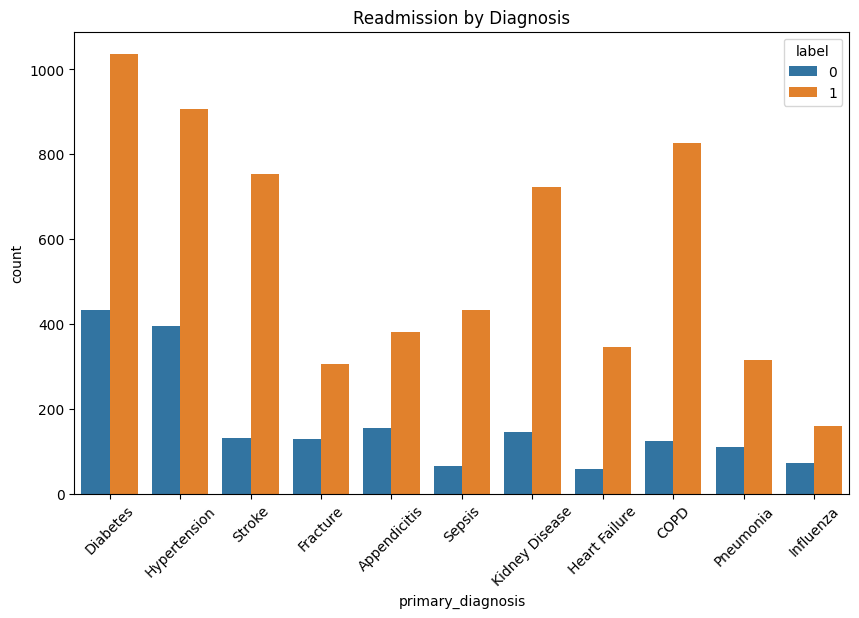

In [27]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='primary_diagnosis', hue='label')
plt.xticks(rotation=45)
plt.title('Readmission by Diagnosis')
plt.show()

11. Feature Engineering

In [ ]:
# Convert date column
df['admission_date'] = pd.to_datetime(df['admission_date'])

# Extract date features

df['admission_year'] = df['admission_date'].dt.year
df['admission_month'] = df['admission_date'].dt.month

# Drop unnecessary columns

df.drop(columns=['patient_id', 'admission_date'], inplace=True)



In [30]:
df.head()

,season,age,gender,region,primary_diagnosis,comorbidities_count,length_of_stay,treatment_type,medications_count,followup_visits_last_year,prev_readmissions,insurance_type,discharge_disposition,readmission_risk_score,label,admission_year,admission_month
0,Spring,66,Male,South,Diabetes,5,6,Interventional,8,6,1,Medicare,Home Health,0.92,1,2022,4
1,Fall,55,Male,South,Diabetes,4,6,Interventional,6,4,3,Private,Home Health,0.88,1,2021,9
2,Spring,69,Female,West,Hypertension,6,8,Medical,9,6,2,Medicare,Skilled Nursing,0.97,1,2023,4
3,Summer,83,Male,South,Stroke,6,11,Medical,11,4,2,Medicare,Skilled Nursing,0.97,1,2023,8
4,Fall,54,Female,North,Stroke,4,10,Medical,6,2,1,Uninsured,Home Health,0.83,1,2021,11


12. Define Features and Target

In [31]:
X = df.drop('label', axis=1)
y = df['label']

13. Identify Numerical and Categorical Columns

In [32]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print('Categorical Columns:', categorical_cols)
print('\nNumerical Columns:', numerical_cols)

Categorical Columns: Index(['season', 'gender', 'region', 'primary_diagnosis', 'treatment_type',
       'insurance_type', 'discharge_disposition'],
      dtype='str')

Numerical Columns: Index(['age', 'comorbidities_count', 'length_of_stay', 'medications_count',
       'followup_visits_last_year', 'prev_readmissions',
       'readmission_risk_score', 'admission_year', 'admission_month'],
      dtype='str')


14. Preprocessing Pipeline

In [33]:
# Numerical pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

15. Train-Test Split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train Shape:', X_train.shape)
print('Test Shape:', X_test.shape)

Train Shape: (6400, 16)
Test Shape: (1600, 16)


16. Define Models

In [35]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss')
}

17. Train and Evaluate Models

In [36]:
results = []
trained_models = {}

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })
    
    trained_models[name] = pipeline
    
    print(f'\n{name}')
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.64      0.43      0.51       363
           1       0.85      0.93      0.89      1237

    accuracy                           0.81      1600
   macro avg       0.74      0.68      0.70      1600
weighted avg       0.80      0.81      0.80      1600


Random Forest
              precision    recall  f1-score   support

           0       0.58      0.38      0.46       363
           1       0.83      0.92      0.87      1237

    accuracy                           0.80      1600
   macro avg       0.70      0.65      0.67      1600
weighted avg       0.78      0.80      0.78      1600


SVM
              precision    recall  f1-score   support

           0       0.64      0.34      0.44       363
           1       0.83      0.94      0.88      1237

    accuracy                           0.81      1600
   macro avg       0.73      0.64      0.66      1600
weighted avg       0.79      0.81

18. Model Comparison

In [38]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC AUC', ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.815000,0.847232,0.928052,0.885802,0.843461
1,Random Forest,0.795625,0.834068,0.918351,0.874182,0.824809
4,XGBoost,0.775000,0.827973,0.894907,0.860140,0.799742
2,SVM,0.806250,0.829424,0.943411,0.882753,0.777035
3,KNN,0.778125,0.836128,0.886823,0.860730,0.765982


19. Visualize Model Performance

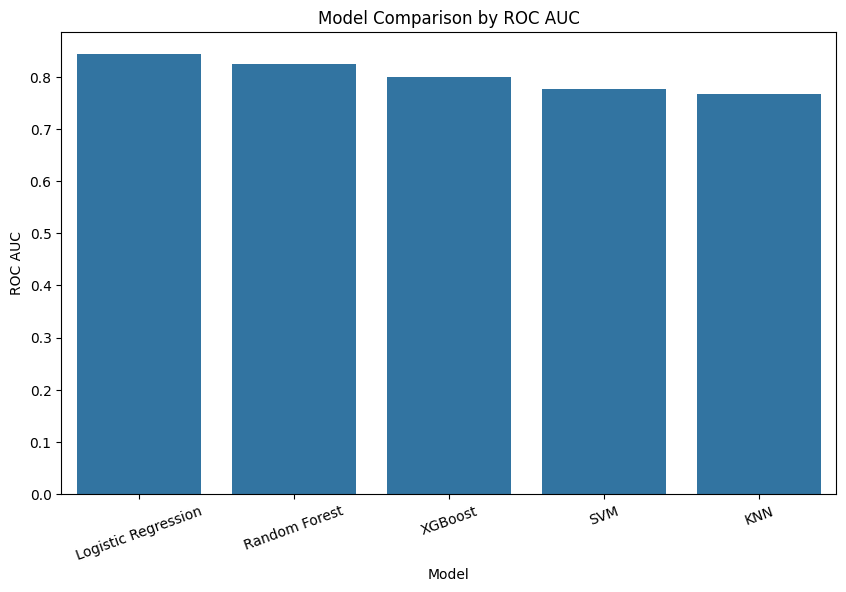

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='Model', y='ROC AUC')
plt.xticks(rotation=20)
plt.title('Model Comparison by ROC AUC')
plt.show()

20. Confusion Matrix for Best Model

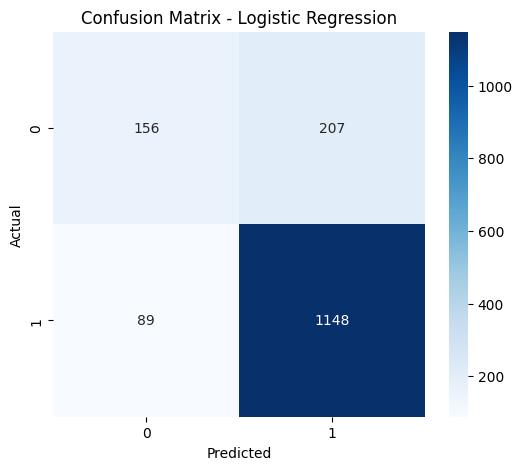

In [40]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

# Predictions

y_pred_best = best_model.predict(X_test)

# Confusion matrix

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

21. ROC Curve

<Figure size 800x600 with 0 Axes>

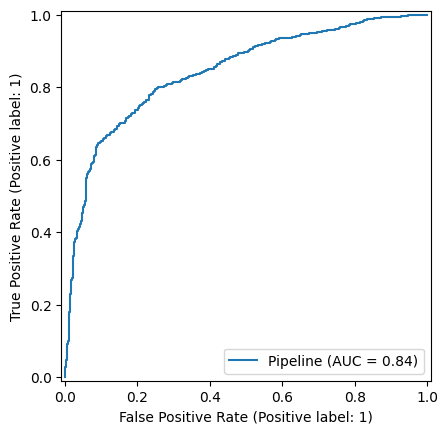

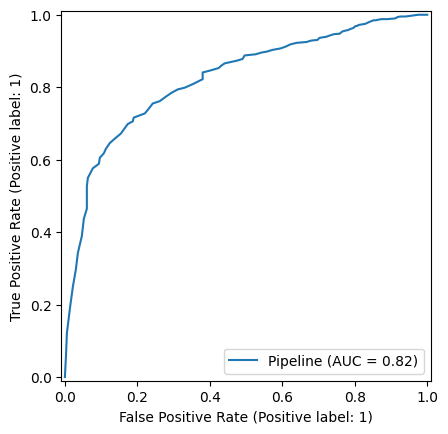

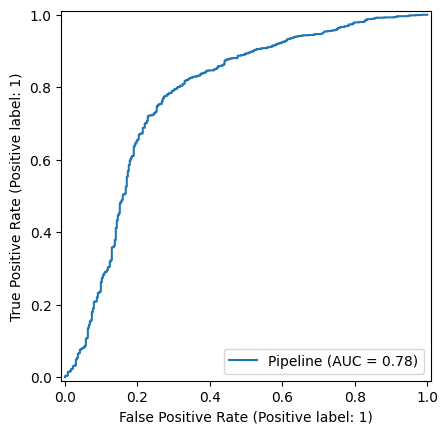

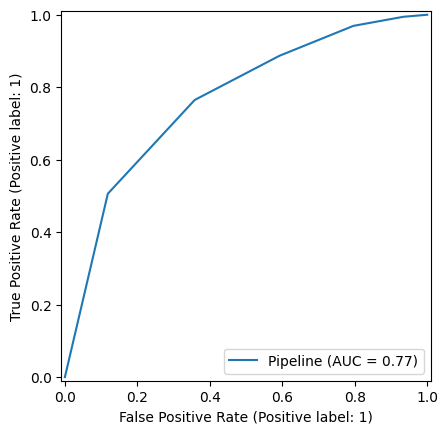

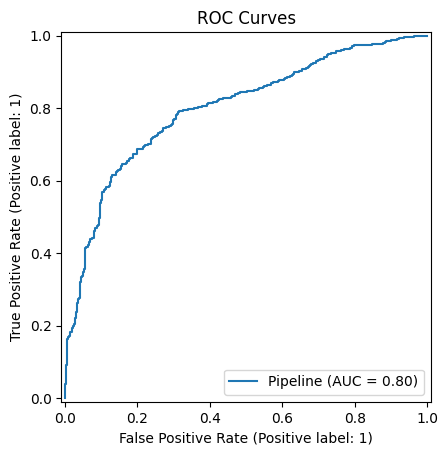

In [41]:
plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test)

plt.title('ROC Curves')
plt.show()

22. Feature Importance (Random Forest)

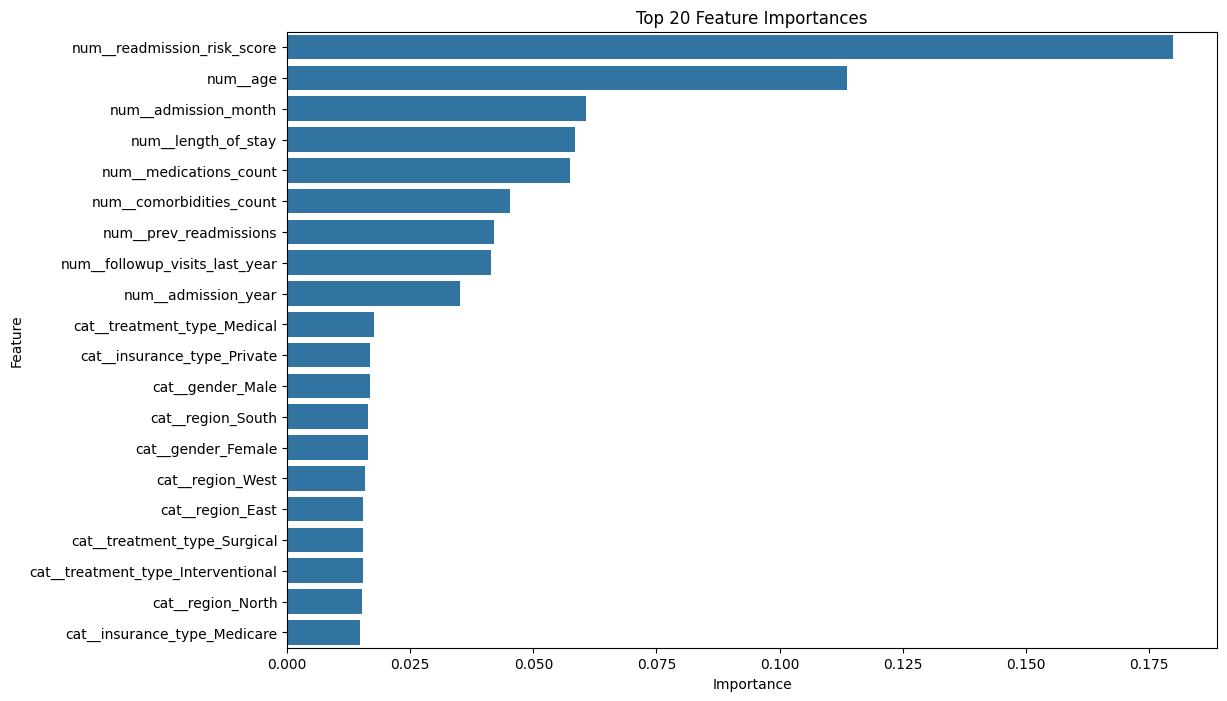

In [42]:
rf_model = trained_models['Random Forest']

# Get transformed feature names
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Feature importance
importances = rf_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(12,8))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Top 20 Feature Importances')
plt.show()

23. Permutation Importance

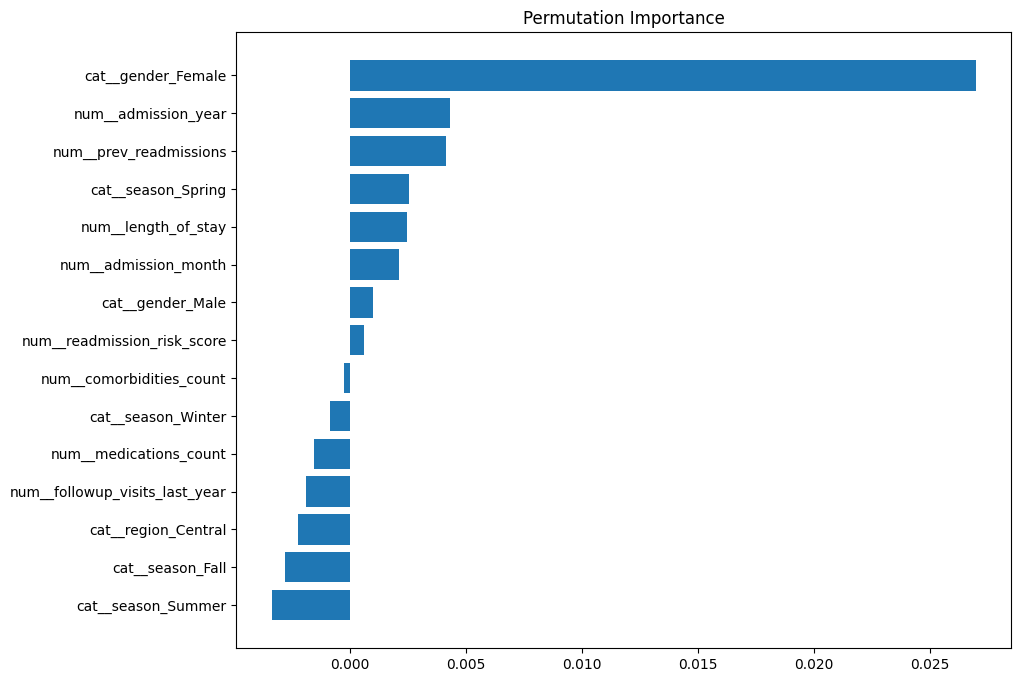

In [43]:
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10,8))
plt.barh(
    np.array(feature_names)[sorted_idx][-15:],
    perm_importance.importances_mean[sorted_idx][-15:]
)

plt.title('Permutation Importance')
plt.show()

24. SHAP Explainability

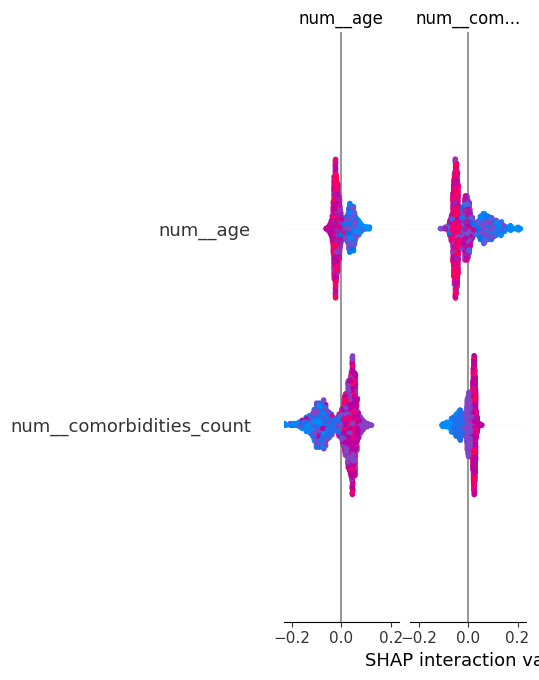

In [44]:
# Preprocess test data
X_test_processed = rf_model.named_steps['preprocessor'].transform(X_test)

# Get classifier
classifier = rf_model.named_steps['classifier']

# SHAP explainer
explainer = shap.TreeExplainer(classifier)

# SHAP values
shap_values = explainer.shap_values(X_test_processed)

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

25. Save Best Model

In [45]:
import joblib

joblib.dump(best_model, 'best_readmission_model.pkl')

print('Best model saved successfully.')

Best model saved successfully.


26. Load Saved Model

In [46]:
loaded_model = joblib.load('best_readmission_model.pkl')

print('Model loaded successfully.')

Model loaded successfully.


27. Predict New Patient

In [47]:
sample_patient = X_test.iloc[[0]]

prediction = loaded_model.predict(sample_patient)
probability = loaded_model.predict_proba(sample_patient)

print('Prediction:', prediction)
print('Probability:', probability)

Prediction: [1]
Probability: [[0.04628508 0.95371492]]


28. Final Conclusion

In [48]:
print('Best Performing Model:')
print(results_df.iloc[0])

Best Performing Model:
Model        Logistic Regression
Accuracy                   0.815
Precision               0.847232
Recall                  0.928052
F1 Score                0.885802
ROC AUC                 0.843461
Name: 0, dtype: object
